## Data Visualization with Seaborn

I am following the CampusX Lectures on Data Visualization with Seaborn.

> Part-1

- Lecture Link: [https://www.youtube.com/watch?v=DWVLRhnuGqI](https://www.youtube.com/watch?v=DWVLRhnuGqI)

**Why Seaborn?**

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

**Types of Functions**

Seaborn, built on Matplotlib, offers two main types of functions for creating plots:

1. Axes-level Functions:
   - Create a single plot within a single set of axes.
   - Allow for detailed customization of individual plots.
   - Suitable for creating specific types of visualizations.

2. Figure-level Functions:
   - Create an entire figure with multiple subplots.
   - Automatically manage the layout of multiple plots.
   - Ideal for creating complex visualizations that involve multiple facets or categories.

**Main Classification**

1. Relational Plot
2. Distribution Plot
3. Categorical Plot
4. Regression Plot
5. Matrix Plot
6. Multiplots

In [1]:
# import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Relational Plot

- Shows relationships between two continuous variables
- Bivariate analysis
- Use to spot trends, patterns, or correlations
  
- Plots under this section:
  - scatter plots
  - line plots

- Quick insights:
  
  - Compare variables easily
  - Highlight outliers or clusters
  - Track changes over time

### Scatter Plot

- Used to visualize the relationship between two continuous variables
- Each point represents an observation in the dataset

In [2]:
# importing dataset
tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

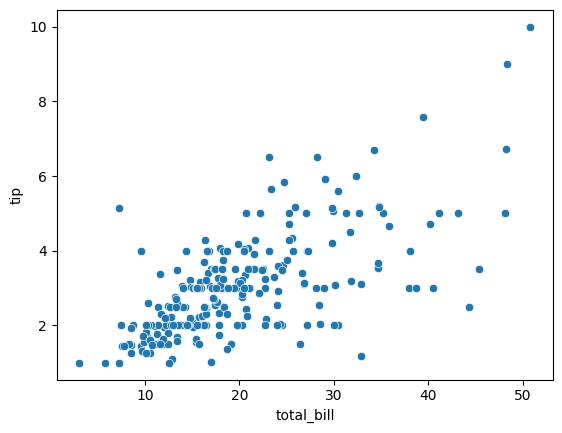

In [4]:
# scatter plot -> axes level function
sns.scatterplot(data=tips, x='total_bill', y='tip')

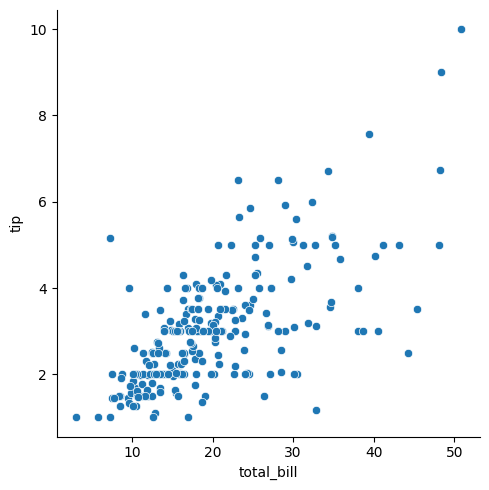

In [5]:
# scatter plot using relplot -> figure level function
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter')

**hue parameter:** allows for easy coloring of data points based on categorical variables

<Axes: xlabel='total_bill', ylabel='tip'>

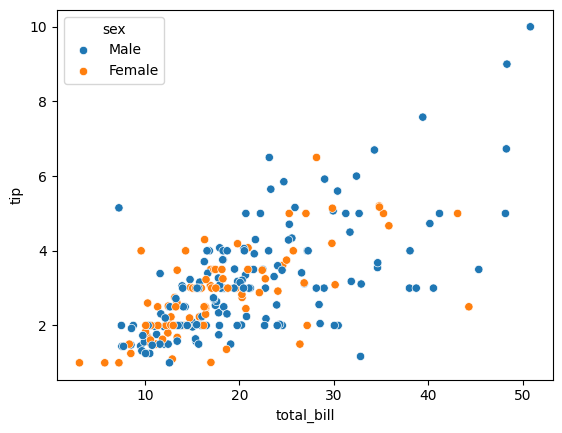

In [6]:
# using hue parameter to color the data points based on 'sex' category
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex')

Using different parameters like `size` and `style`, you can further differentiate data points based on additional categorical variables.

<Axes: xlabel='total_bill', ylabel='tip'>

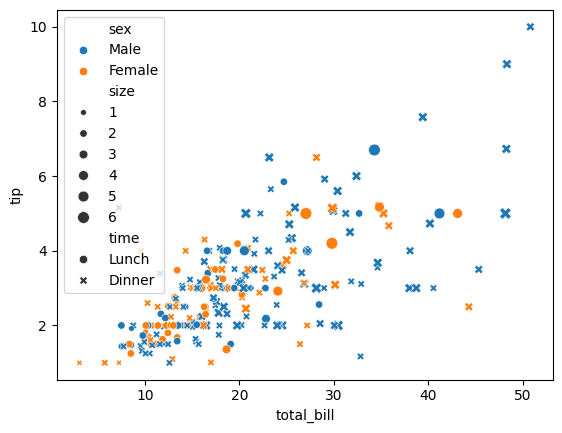

In [7]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', style='time', size='size')

### Line Plot

- Used to visualize trends over time or ordered categories
- Connects data points with lines to show continuity

In [8]:
# importing data
gap = px.data.gapminder()
temp_df = gap[gap['country'] == 'Pakistan'] # filter data for Pakistan
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1164,Pakistan,Asia,1952,43.436,41346560,684.597144,PAK,586
1165,Pakistan,Asia,1957,45.557,46679944,747.083529,PAK,586
1166,Pakistan,Asia,1962,47.670,53100671,803.342742,PAK,586
1167,Pakistan,Asia,1967,49.800,60641899,942.408259,PAK,586
1168,Pakistan,Asia,1972,51.929,69325921,1049.938981,PAK,586


<Axes: xlabel='year', ylabel='lifeExp'>

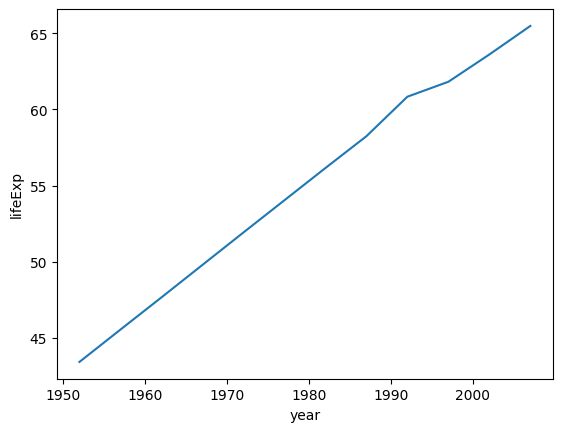

In [9]:
# life expectancy over years in Pakistan
sns.lineplot(data=temp_df, x='year', y='lifeExp')

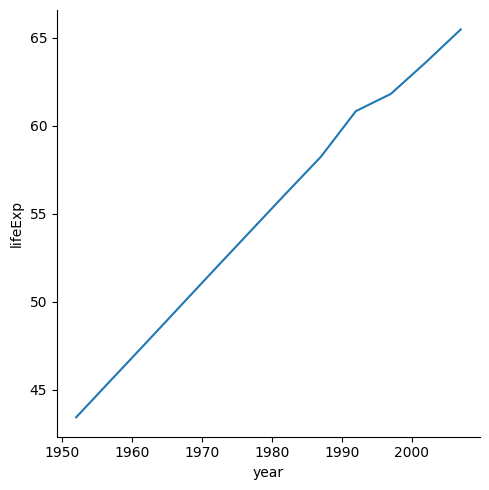

In [10]:
# line plot using relplt
sns.relplot(data=temp_df, x='year', y='lifeExp', kind='line')

In [11]:
temp_df = gap[gap['country'].isin(['India', 'Pakistan', 'China', 'Afghanistan'])]
temp_df.sample(5)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
3,Afghanistan,Asia,1967,34.02000,11537966,836.197138,AFG,4
704,India,Asia,1992,60.22300,872000000,1164.406809,IND,356
1173,Pakistan,Asia,1997,61.81800,135564834,2049.350521,PAK,586
291,China,Asia,1967,58.38112,754550000,612.705693,CHN,156
697,India,Asia,1957,40.24900,409000000,590.061996,IND,356


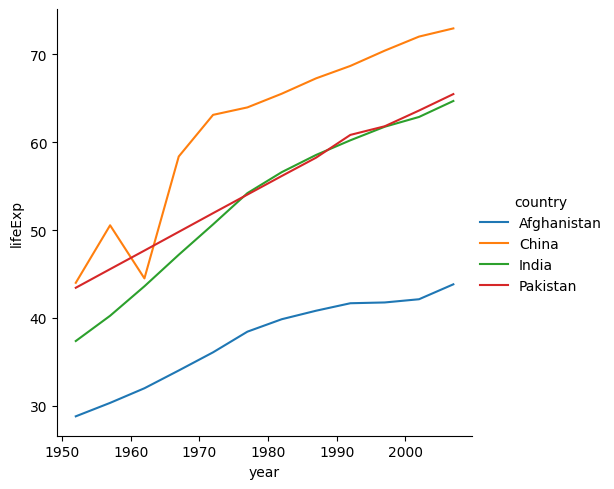

In [12]:
# life expectancy over years across the Pakistan, India, China and Afghanistan
sns.relplot(kind='line', data=temp_df, x='year', y='lifeExp', hue='country')

In [13]:
temp_df = gap[gap['country'].isin(['Nigeria', 'South Africa', 'Pakistan', 'China', 'India', 'Russia', 'United Kingdom', 'United States', 'Canada'])]

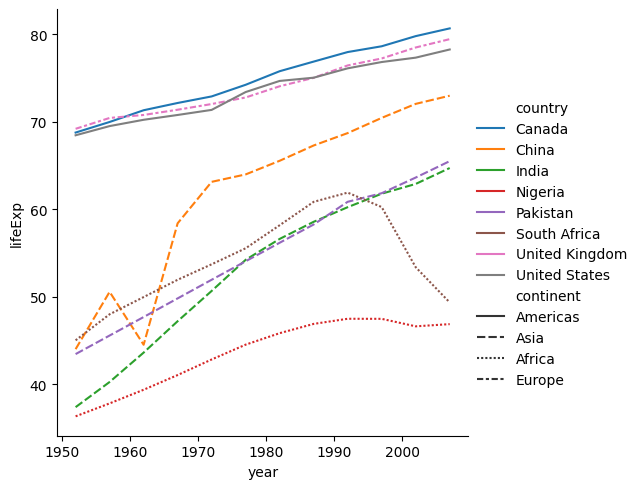

In [14]:
# using style parameter to differentiate continents
sns.relplot(kind='line', data=temp_df, x='year', y='lifeExp', hue='country', style='continent')

**Facet plot** allows for creating multiple subplots based on categorical variables, enabling comparisons across different groups.

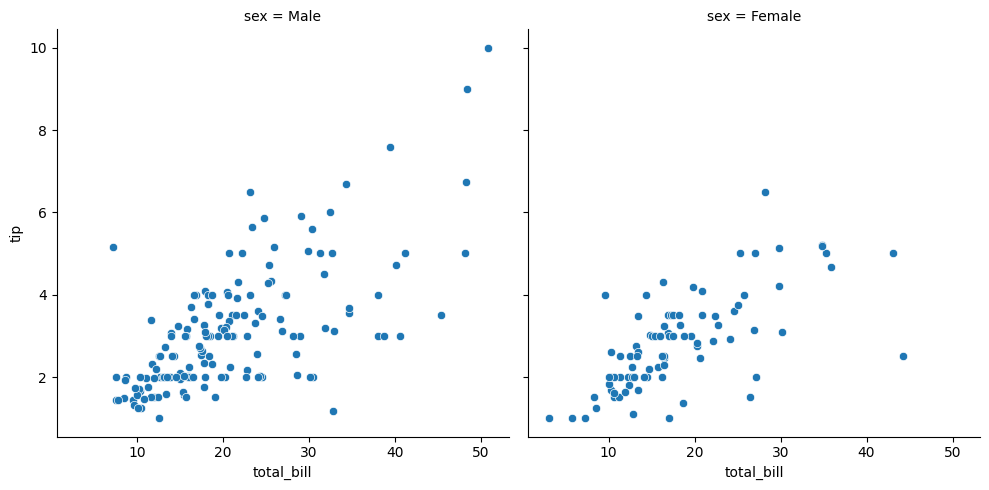

In [15]:
# facet plot columns based
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', col='sex')

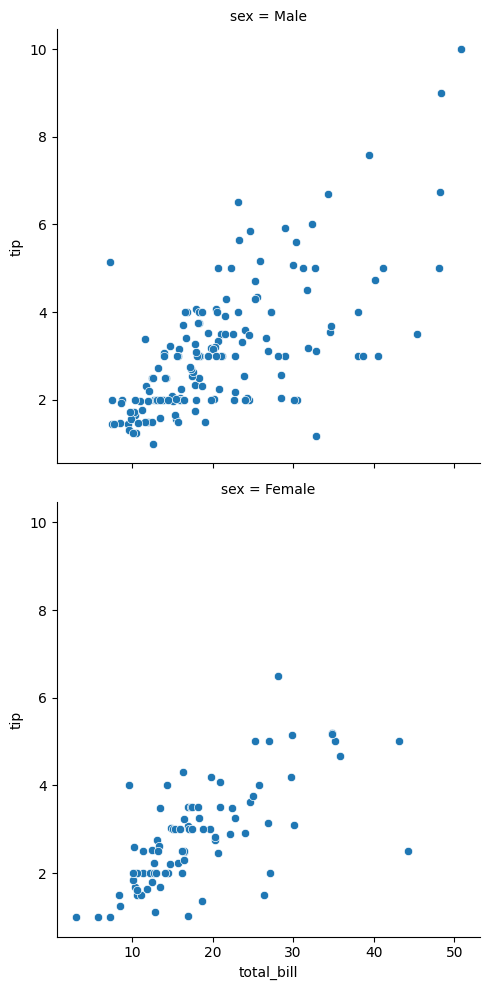

In [16]:
# facet plot rows based
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', row='sex')

In [17]:
tips.sample(1)

,total_bill,tip,sex,smoker,day,time,size
100,11.35,2.5,Female,Yes,Fri,Dinner,2


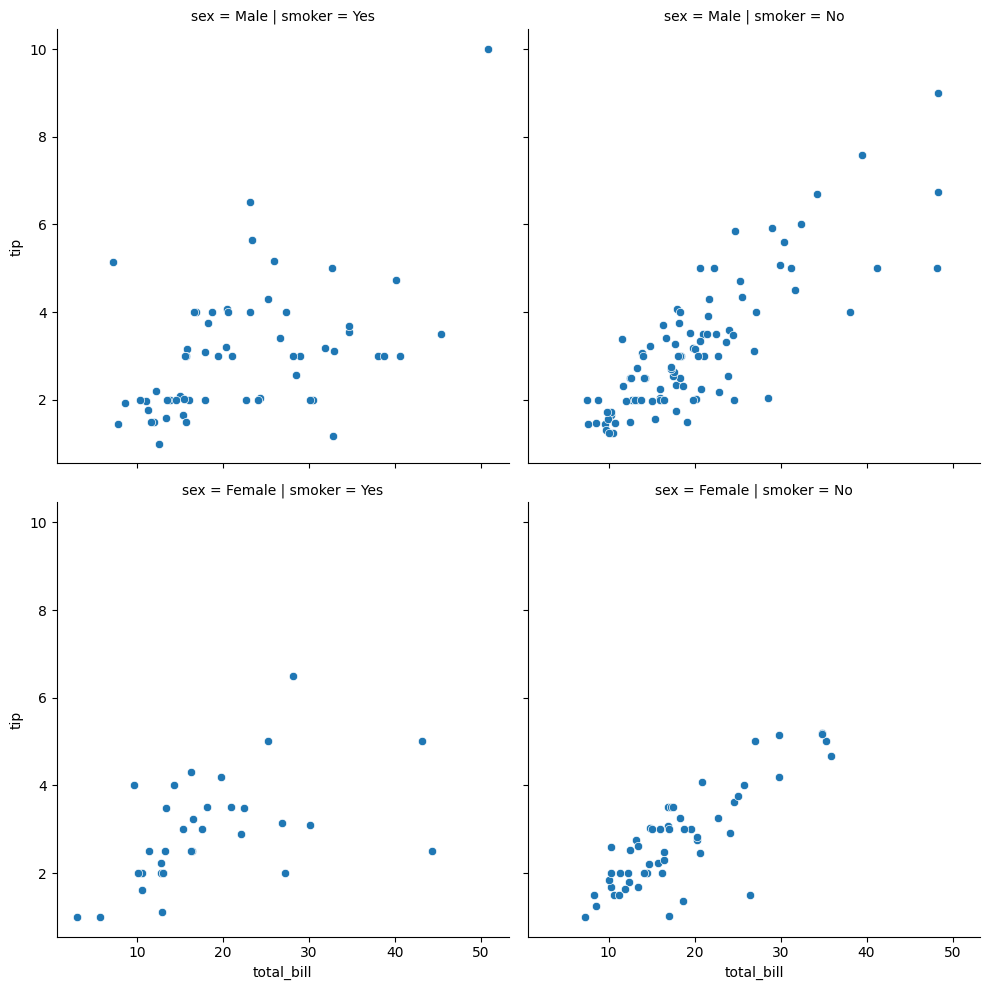

In [18]:
# facet plot with rows and columns based
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', row ='sex', col='smoker')

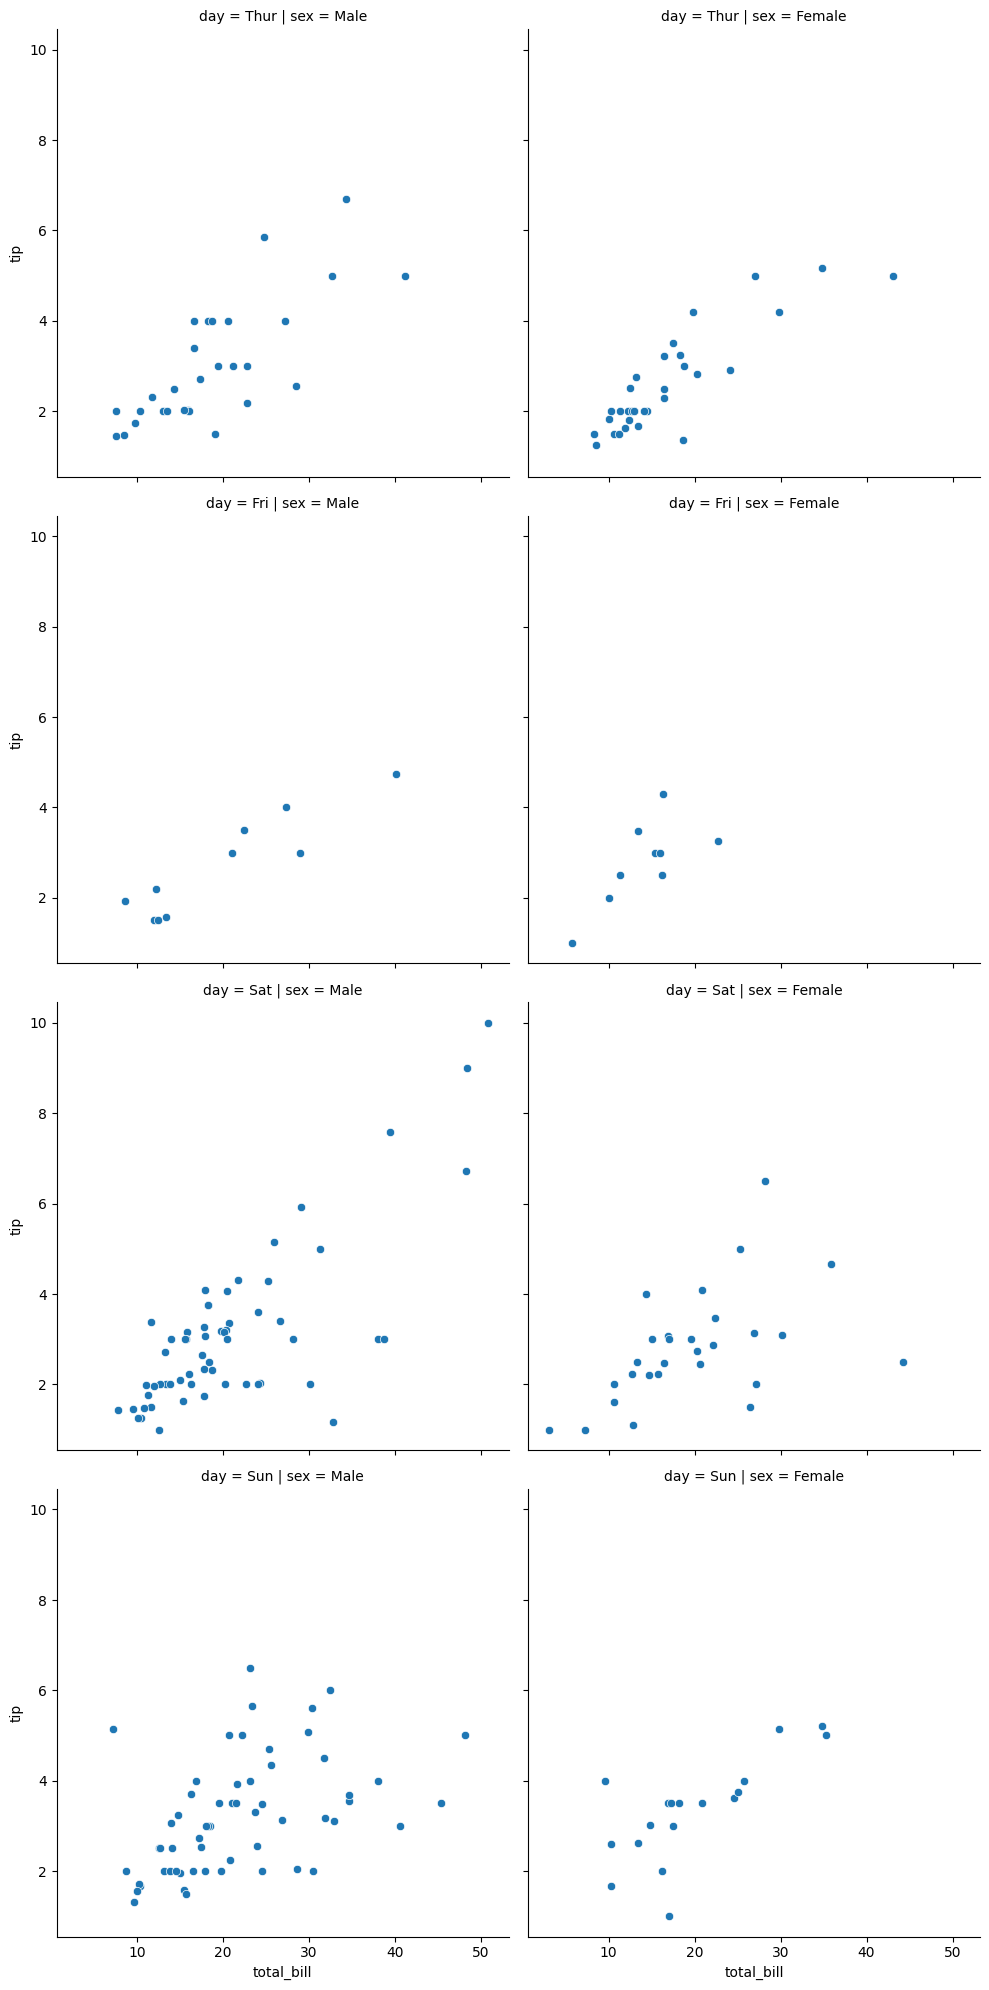

In [19]:
# between days and sex
sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter', row ='day', col='sex')

> Note: We can't make this kind of plot using axes-level function. We have to use figure-level function.

In [20]:
gap.sample(1)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1208,Peru,Americas,1992,66.458,22430449,4446.380924,PER,604


**Column Wrap** allows for wrapping subplots into multiple rows when there are many categories, improving readability and layout.

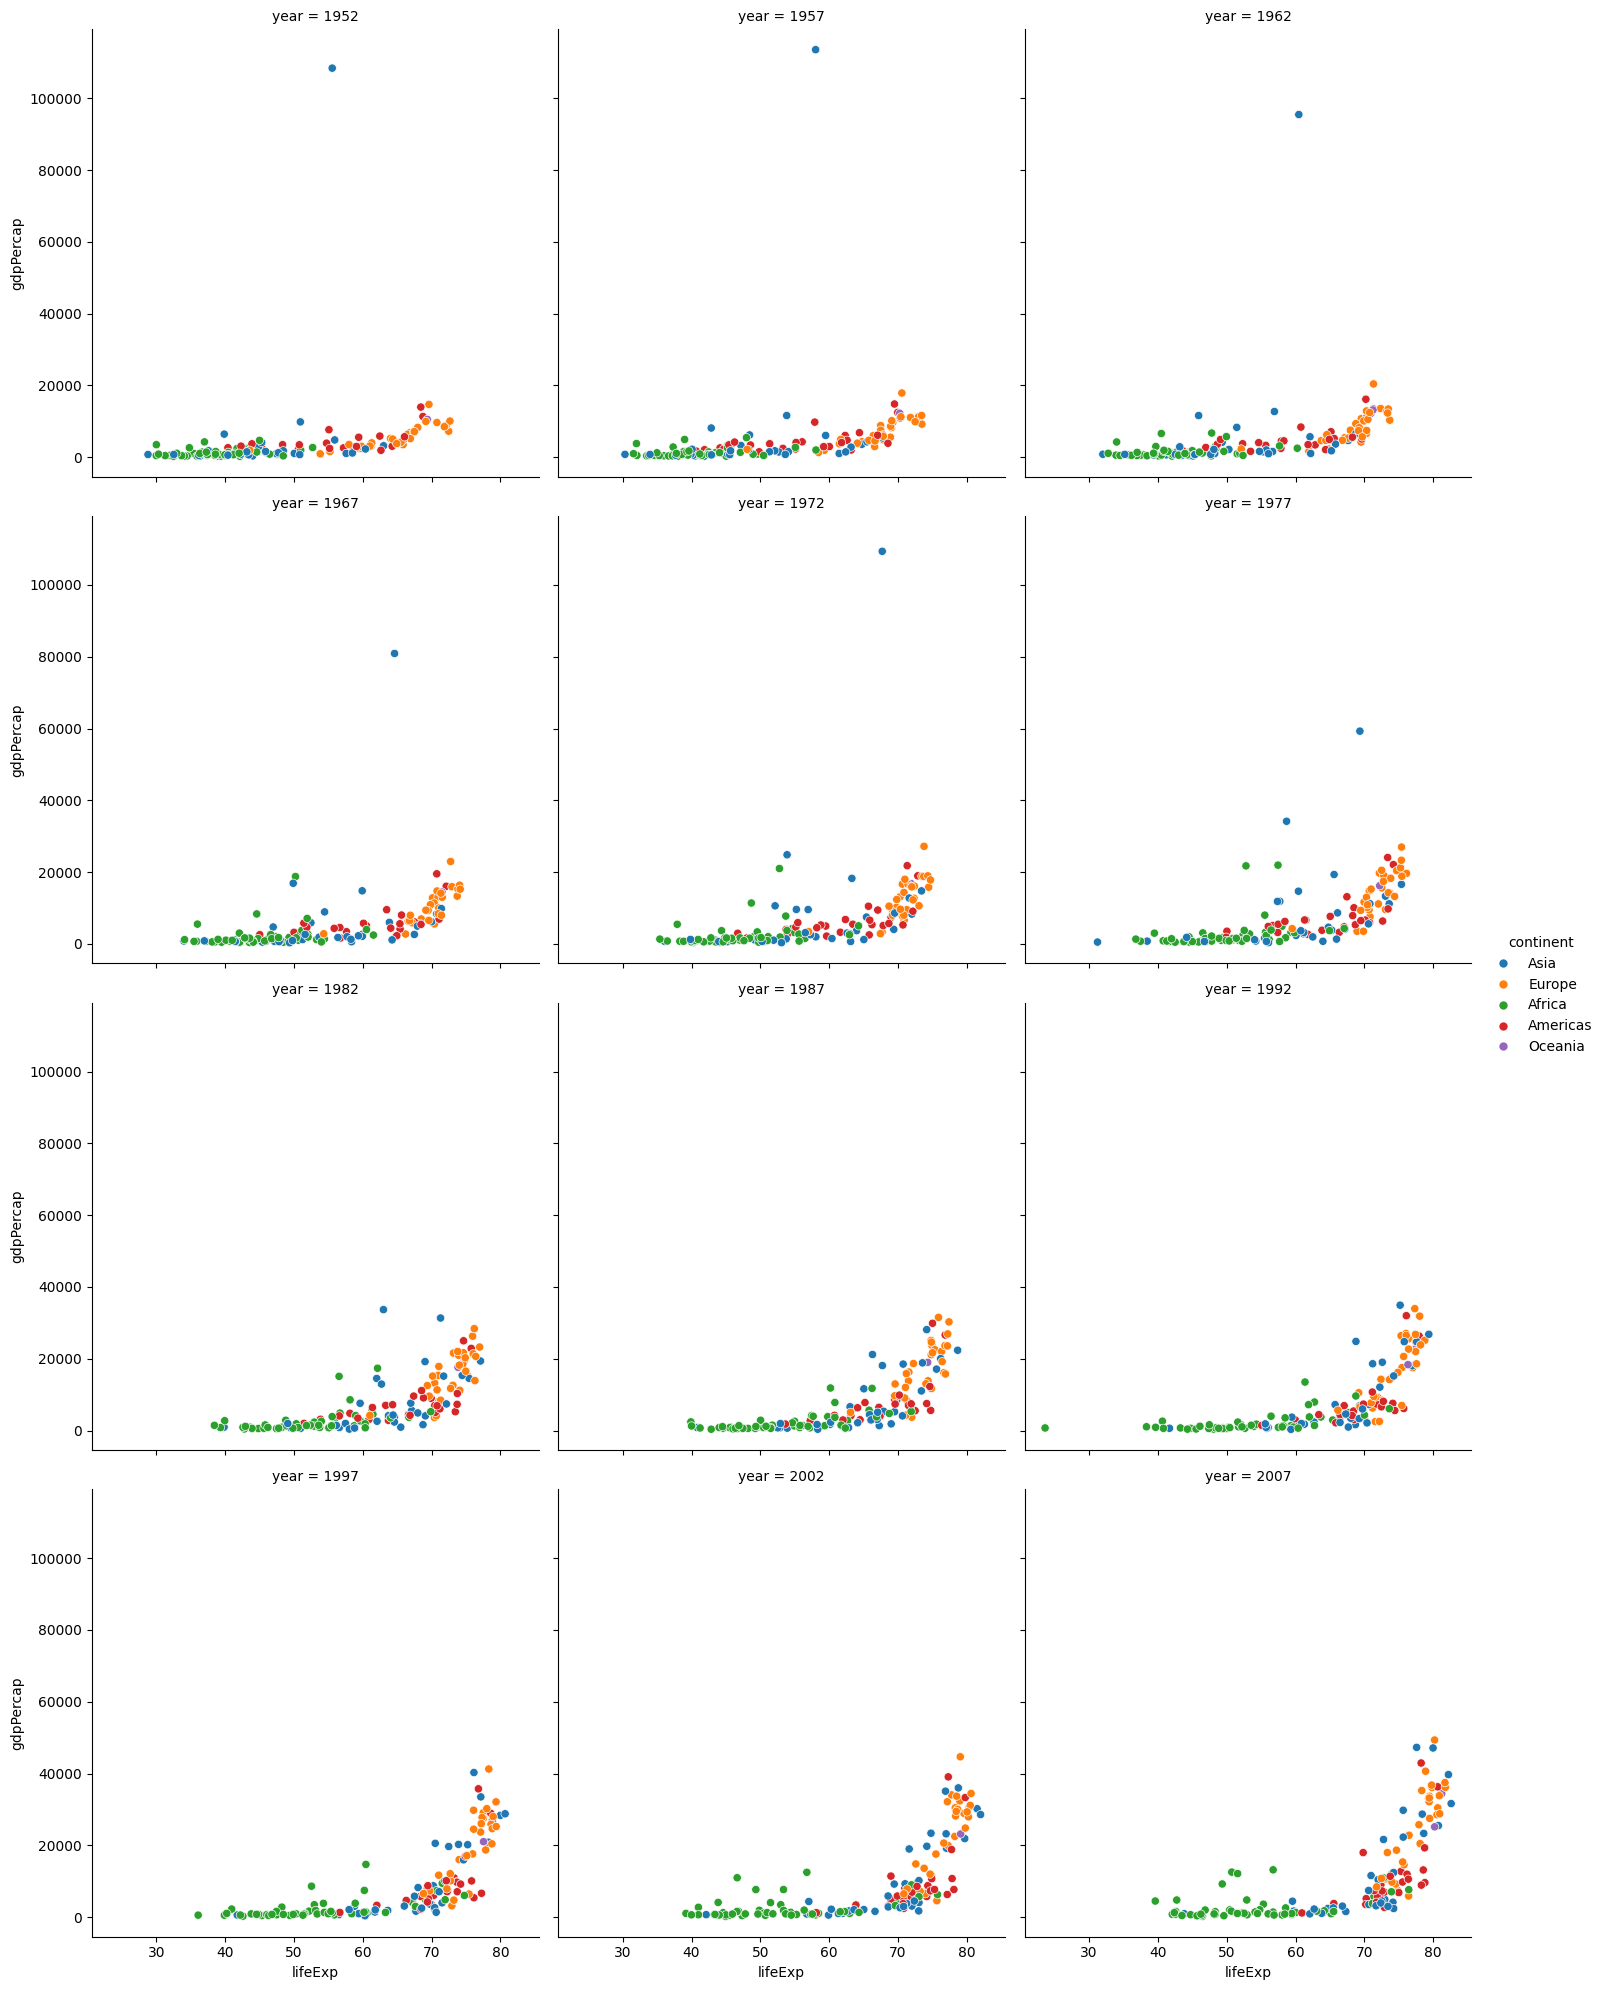

In [21]:
# using col_wrap
sns.relplot(data=gap, x='lifeExp', y='gdpPercap', kind='scatter', hue='continent', col='year', col_wrap=3)

---

## Distribution Plot


- Shows how data values are distributed across one or more variables
- Useful for understanding patterns, spread, and outliers in data

- Plots under this section:

  - histogram
  - kdeplot
  - rugplot

- Quick insights:

  - Spot skewness or symmetry
  - Identify peaks, gaps, or outliers
  - Compare distributions between groups

In [22]:
# figure level -> displot
# axes level -> histplot -> kdeplot -> rugplot

### Histogram

- Visualizes the frequency distribution
- Data is divided into bins
- Height of each bar represents the count of observations within that bin
- Useful for understanding the shape and spread of the data

<Axes: xlabel='total_bill', ylabel='Count'>

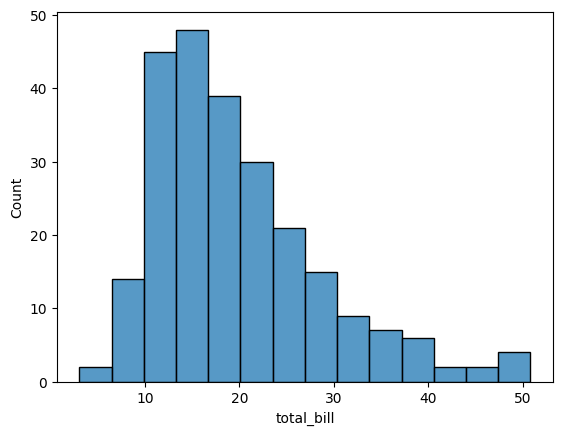

In [23]:
# plotting univariate histogram 
sns.histplot(data=tips, x='total_bill')

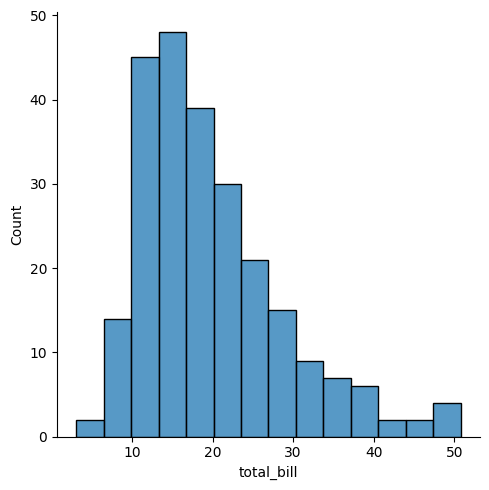

In [ ]:
# plotting histogram using displot (figure level)
sns.displot(data=tips, x='total_bill', kind='hist')

**Bins Parameter** allows you to control the number of bins in the histogram

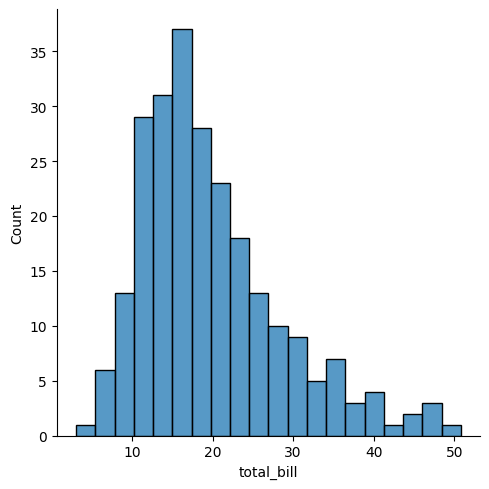

In [25]:
# using bins parameter
sns.displot(data=tips, x='total_bill', kind='hist', bins=20)

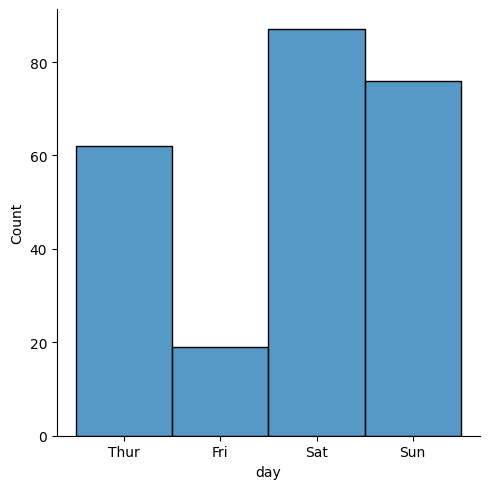

In [26]:
# It’s also possible to visualize the distribution of a categorical variable using the logic of a histogram. 
# Discrete bins are automatically set for categorical variables

# countplot
sns.displot(data=tips, x='day', kind='hist')

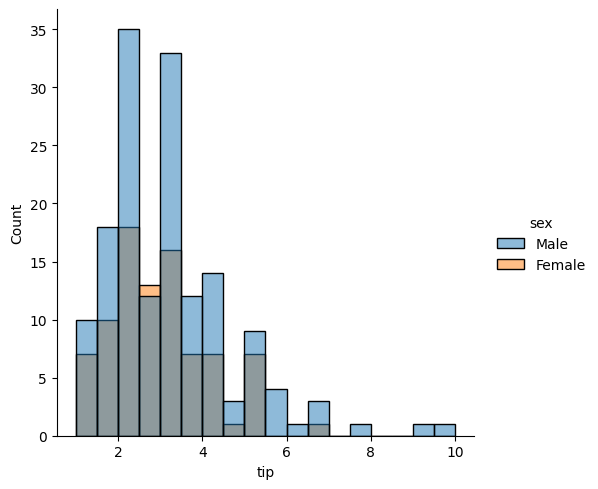

In [27]:
# using hue parameter
sns.displot(data=tips, x='tip', kind='hist', hue='sex')

In [28]:
tips.sample(1)

,total_bill,tip,sex,smoker,day,time,size
88,24.71,5.85,Male,No,Thur,Lunch,2


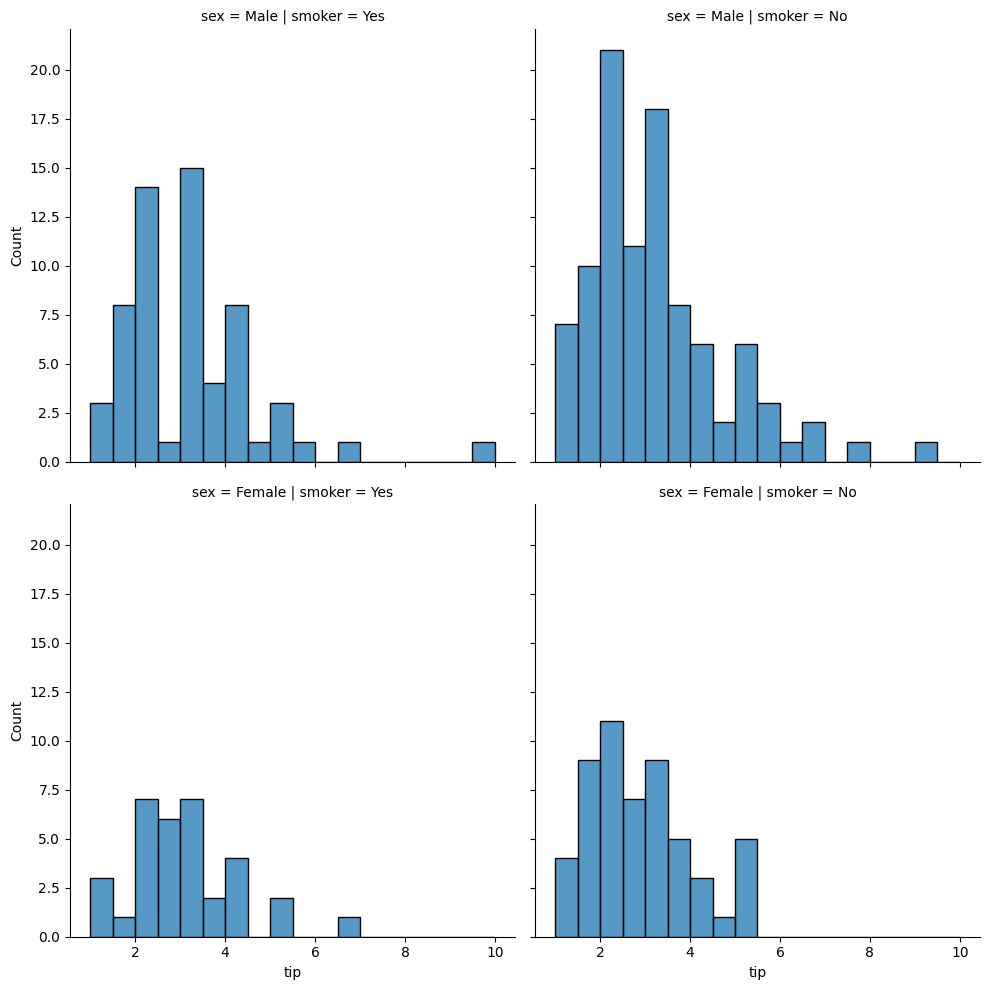

In [29]:
# faceting using col and row
sns.displot(data=tips, x='tip', kind='hist', col='smoker', row='sex')

# Note: faceting only possible with the figure level function (displot), and will not possible with the axis level function (displot)

**Bivariate histogram**

- A bivariate histogram bins the data within rectangles that tile the plot 
- It then shows the count of observations within each rectangle with the fill color

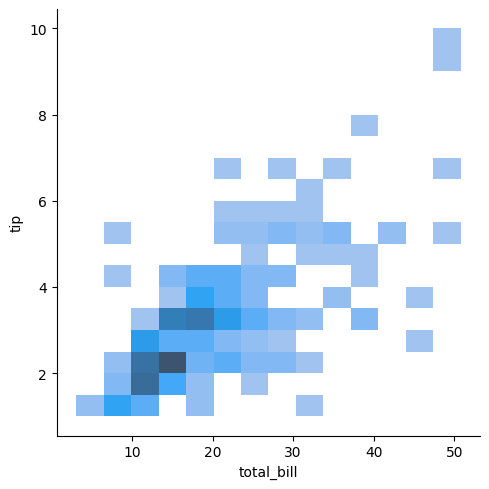

In [30]:
sns.displot(data=tips, x='total_bill', y='tip', kind='hist')

### KDE (Kernel Density Estimation) Plot

- A smoothed version of the histogram
- Estimates the probability density function of a continuous variable
- Useful for visualizing the distribution of data points along a continuous scale

In [31]:
tips.head(1)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2


<Axes: xlabel='total_bill', ylabel='Density'>

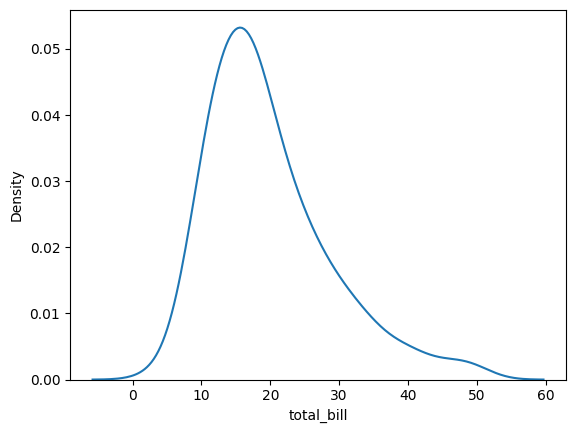

In [ ]:
# plotting kde plot
sns.kdeplot(data=tips, x='total_bill')

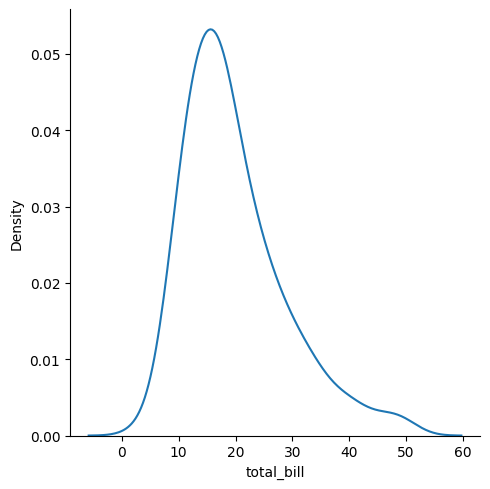

In [33]:
# KDE plot at figure level
sns.displot(data=tips, x='total_bill', kind='kde')

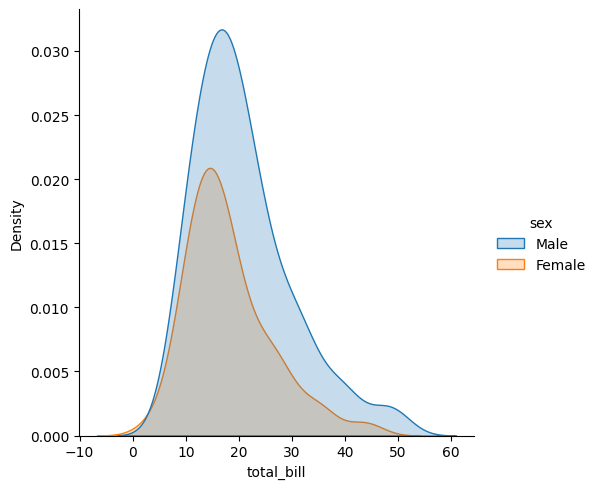

In [34]:
# hue - fill 
sns.displot(data=tips, x='total_bill', kind='kde', hue='sex', fill=True)

**Bivariate Kdeplot**

- A bivariate KDE plot smoothes the (x, y) observations with a 2D Gaussian

In [35]:
tips.sample(1)

,total_bill,tip,sex,smoker,day,time,size
160,21.5,3.5,Male,No,Sun,Dinner,4


<Axes: xlabel='size', ylabel='tip'>

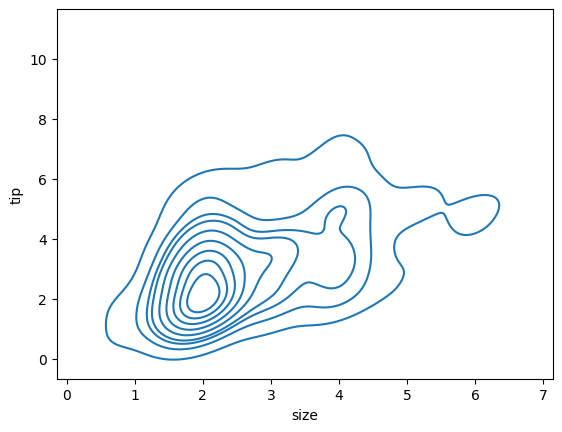

In [36]:
sns.kdeplot(data=tips, x='size', y='tip')

### Rug Plot

- Plot marginal distributions by drawing ticks along the x and y axes.
- This function is intended to complement other plots by showing the location of individual observations in an unobtrusive way.

<Axes: xlabel='total_bill', ylabel='Density'>

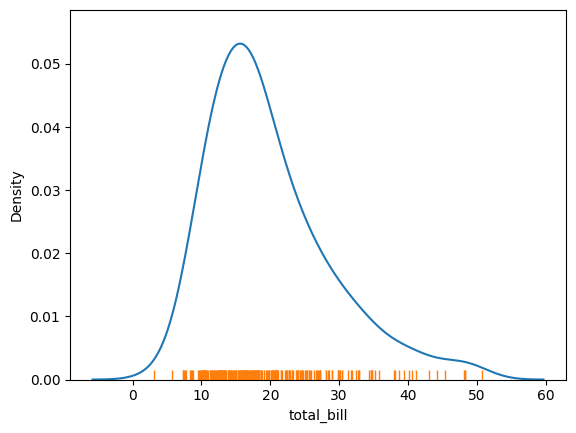

In [37]:
sns.kdeplot(data=tips, x='total_bill')
sns.rugplot(data=tips, x='total_bill')

---

## Matrix Plot

- Used to visualize data in a matrix format
- Each cell represents a value, with color intensity indicating magnitude
- Useful for identifying patterns, correlations, or anomalies in data

- Plots under this section:
  - heatmap
  - clustermap

- Quick insights:
  - Identify correlations between variables
  - Spot clusters or outliers
  - Visualize complex data relationships

### Heatmap

- A heatmap is a graphical representation of data where individual values are represented as colors in a matrix.
- It is used to visualize the magnitude of values across two dimensions, making it easy to identify patterns, correlations, or anomalies in the data.

In [38]:
gap.sample(5)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
36,Angola,Africa,1952,30.015,4232095,3520.610273,AGO,24
889,Liberia,Africa,1957,39.486,975950,620.969990,LBR,430
1338,Serbia,Europe,1982,70.162,9032824,15181.092700,SRB,688
654,Honduras,Americas,1982,60.909,3669448,3121.760794,HND,340
1148,Norway,Europe,1992,77.320,4286357,33965.661150,NOR,578


In [39]:
temp_df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
240,Canada,Americas,1952,68.750,14785584,11367.16112,CAN,124
241,Canada,Americas,1957,69.960,17010154,12489.95006,CAN,124
242,Canada,Americas,1962,71.300,18985849,13462.48555,CAN,124
243,Canada,Americas,1967,72.130,20819767,16076.58803,CAN,124
244,Canada,Americas,1972,72.880,22284500,18970.57086,CAN,124
...,...,...,...,...,...,...,...,...
1615,United States,Americas,1987,75.020,242803533,29884.35041,USA,840
1616,United States,Americas,1992,76.090,256894189,32003.93224,USA,840
1617,United States,Americas,1997,76.810,272911760,35767.43303,USA,840
1618,United States,Americas,2002,77.310,287675526,39097.09955,USA,840


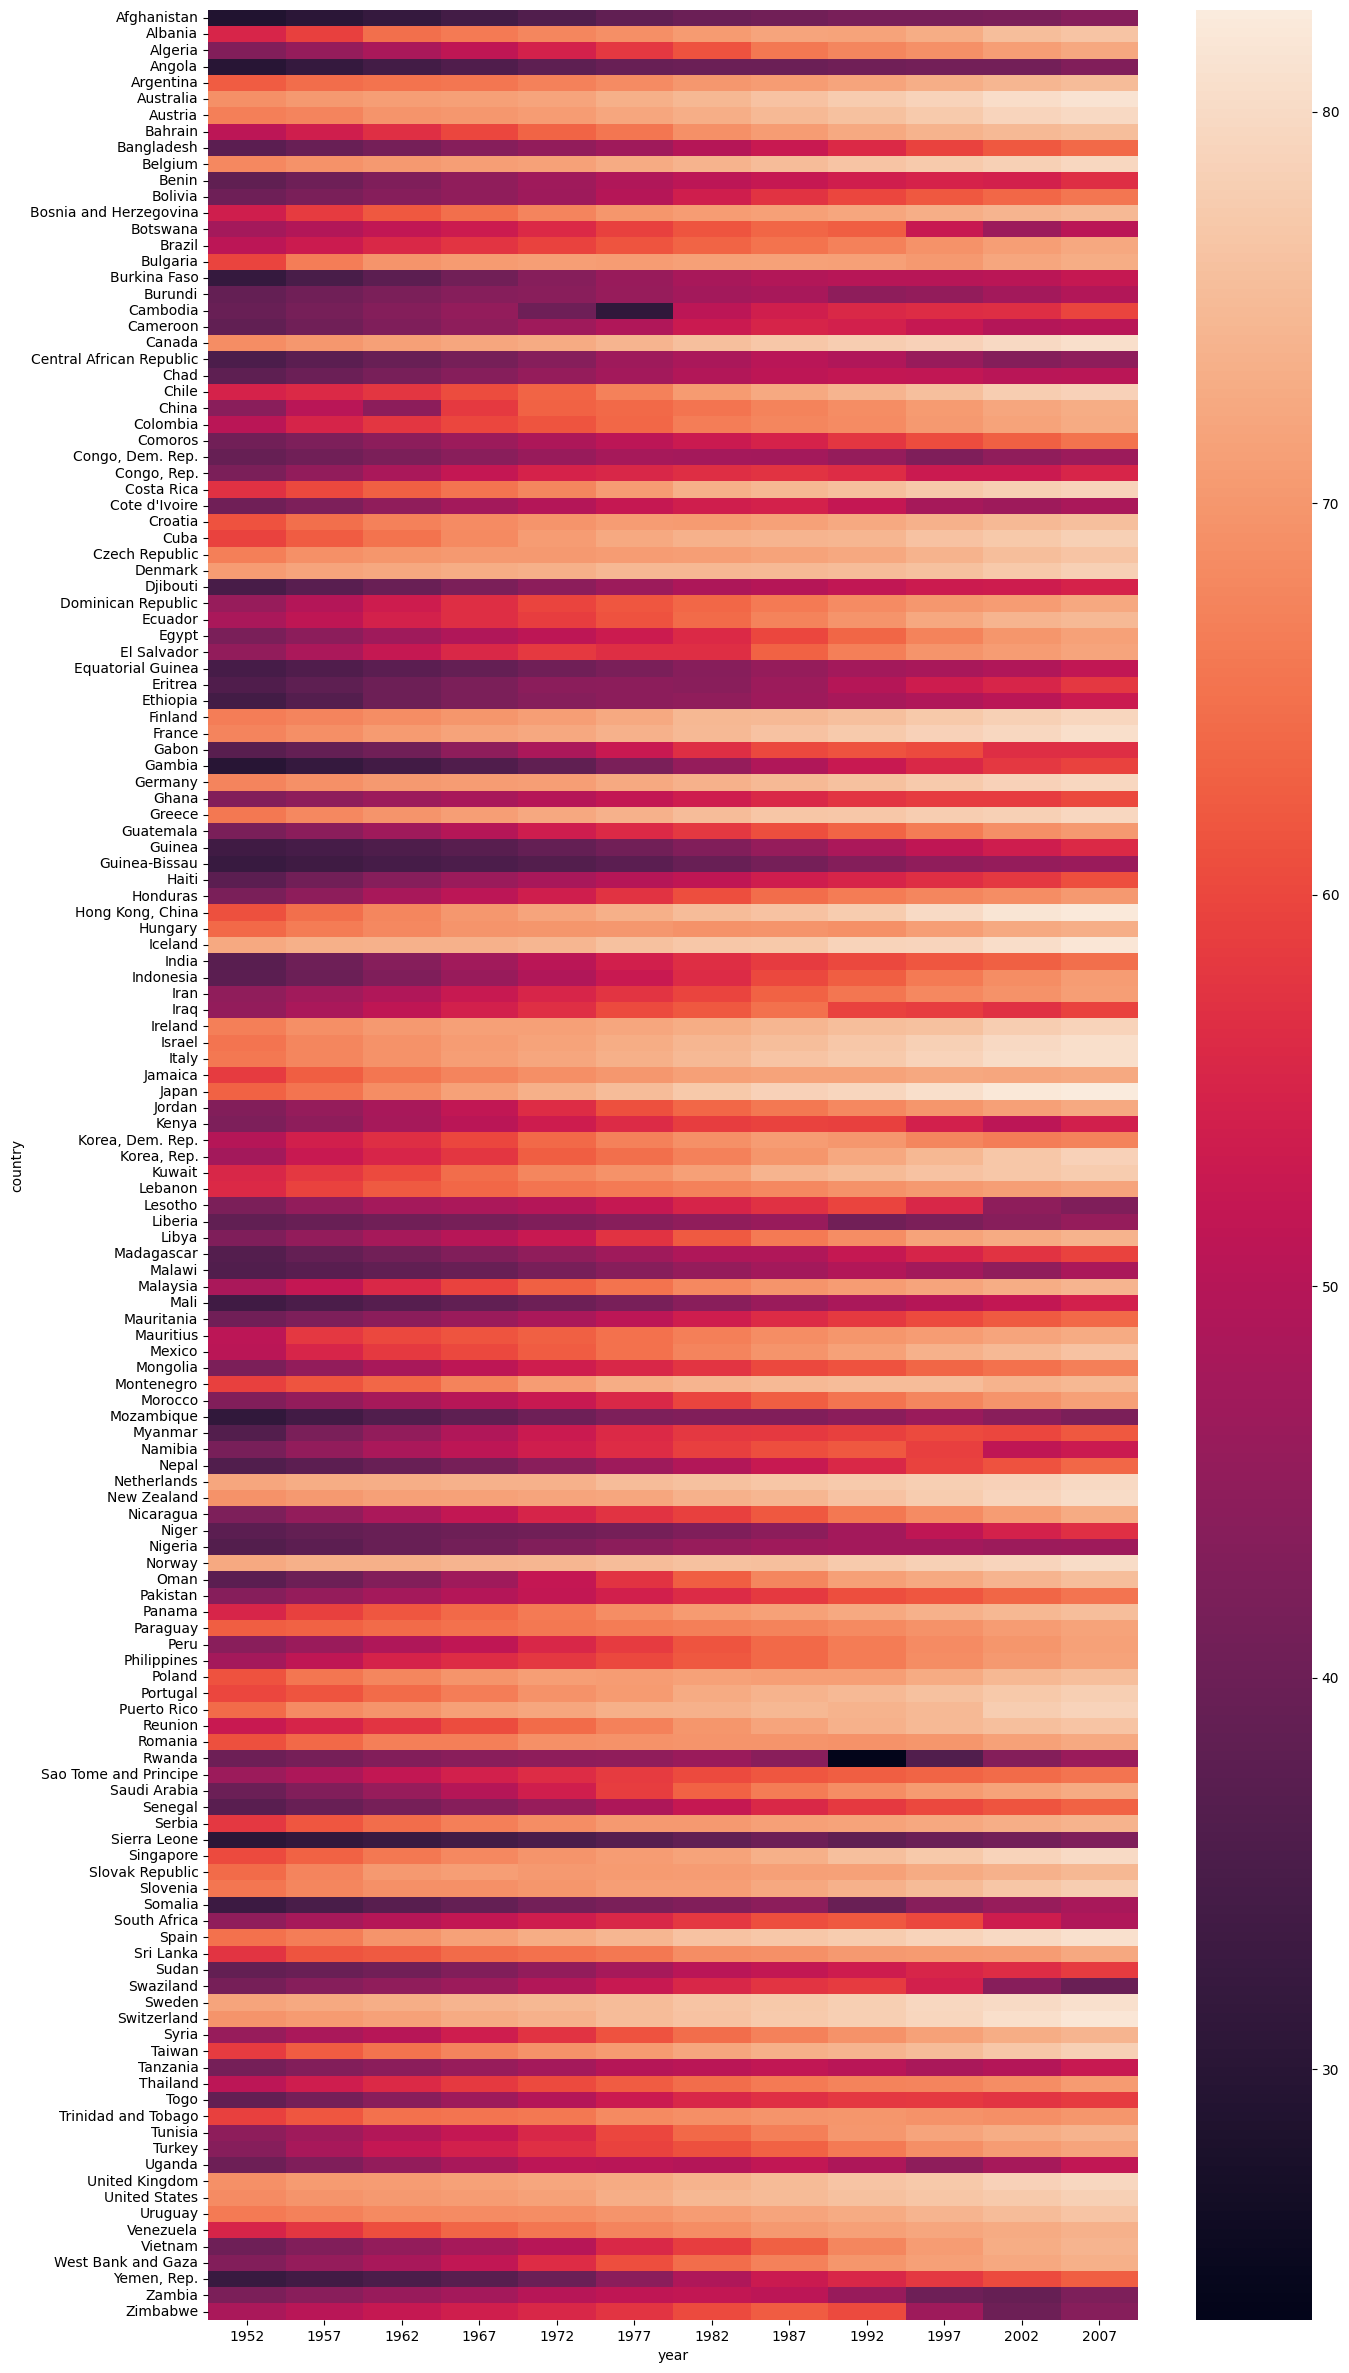

In [40]:
temp_df = gap.pivot(index='country', columns='year', values='lifeExp')

# axes level function
plt.figure(figsize=(15,30))
ax = sns.heatmap(temp_df)

**annot** parameter adds numerical values to each cell in the heatmap for better interpretability.

<Axes: xlabel='year', ylabel='country'>

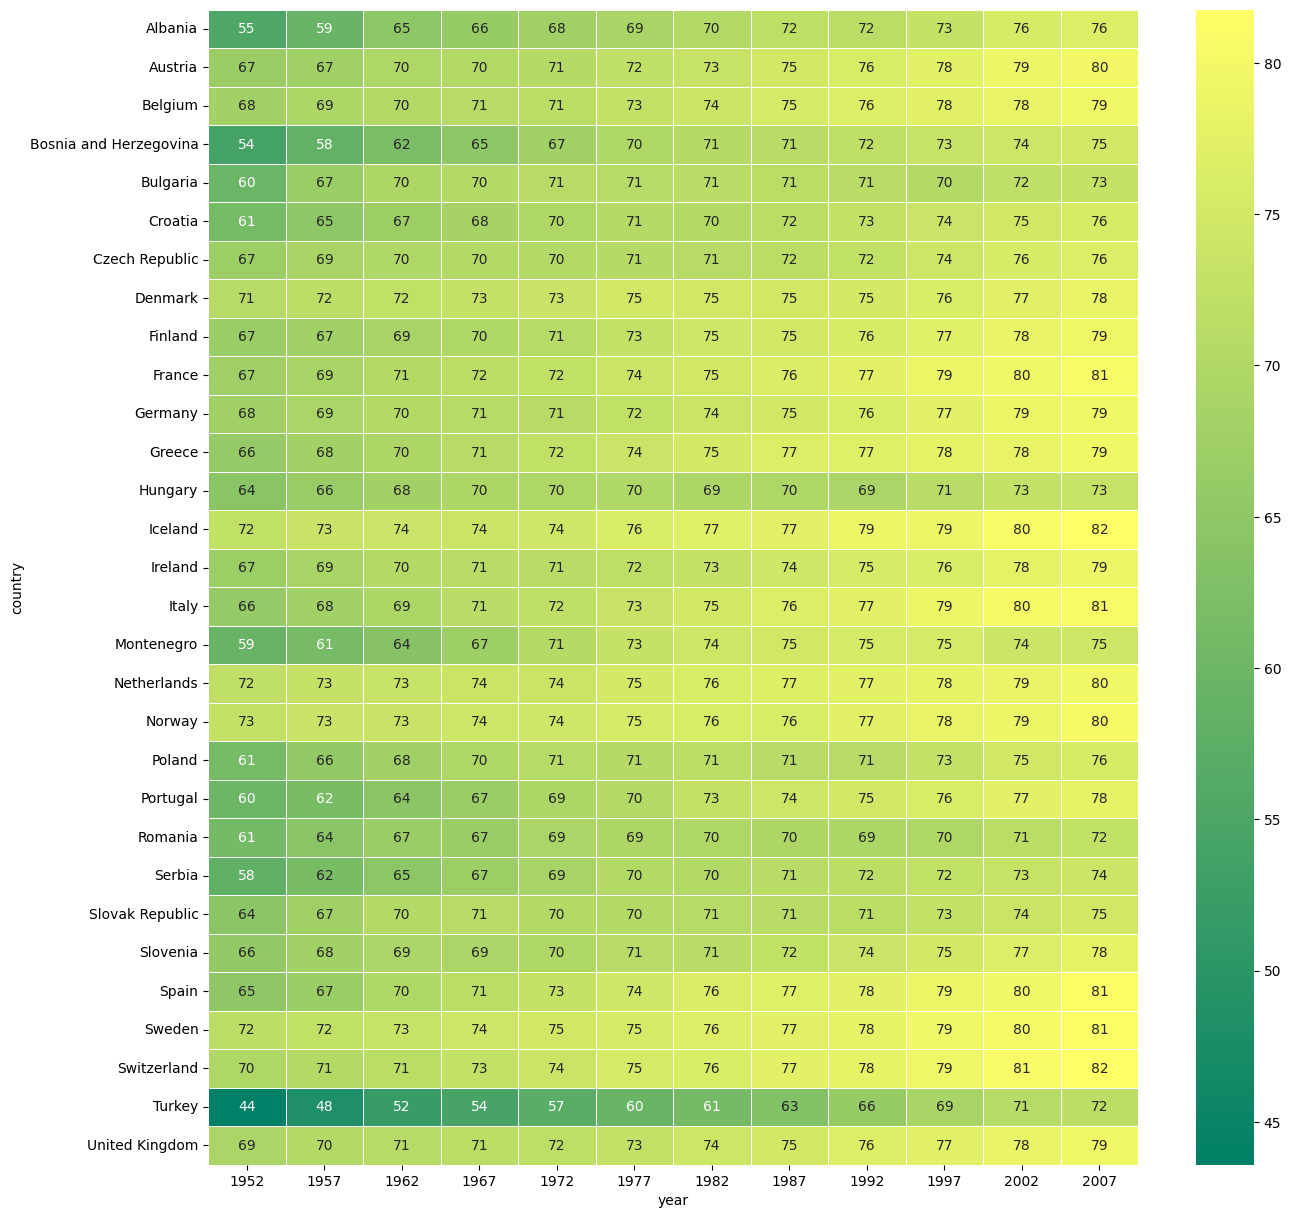

In [41]:
temp_df = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')

plt.figure(figsize=(15,15))
sns.heatmap(temp_df, annot=True, linewidth=0.5, cmap='summer')

### Clustermap

- A clustermap is a type of heatmap that includes hierarchical clustering of both rows and columns.
- It is used to visualize the relationships and patterns in data by grouping similar rows and columns together, making it easier to identify clusters and correlations.

In [42]:
# loading iris dataset
iris = sns.load_dataset('iris')
iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
90,5.5,2.6,4.4,1.2,versicolor
107,7.3,2.9,6.3,1.8,virginica
62,6.0,2.2,4.0,1.0,versicolor
37,4.9,3.6,1.4,0.1,setosa


> Note: For clustermap, we need to install scipy library as well.

In [ ]:
import scipy

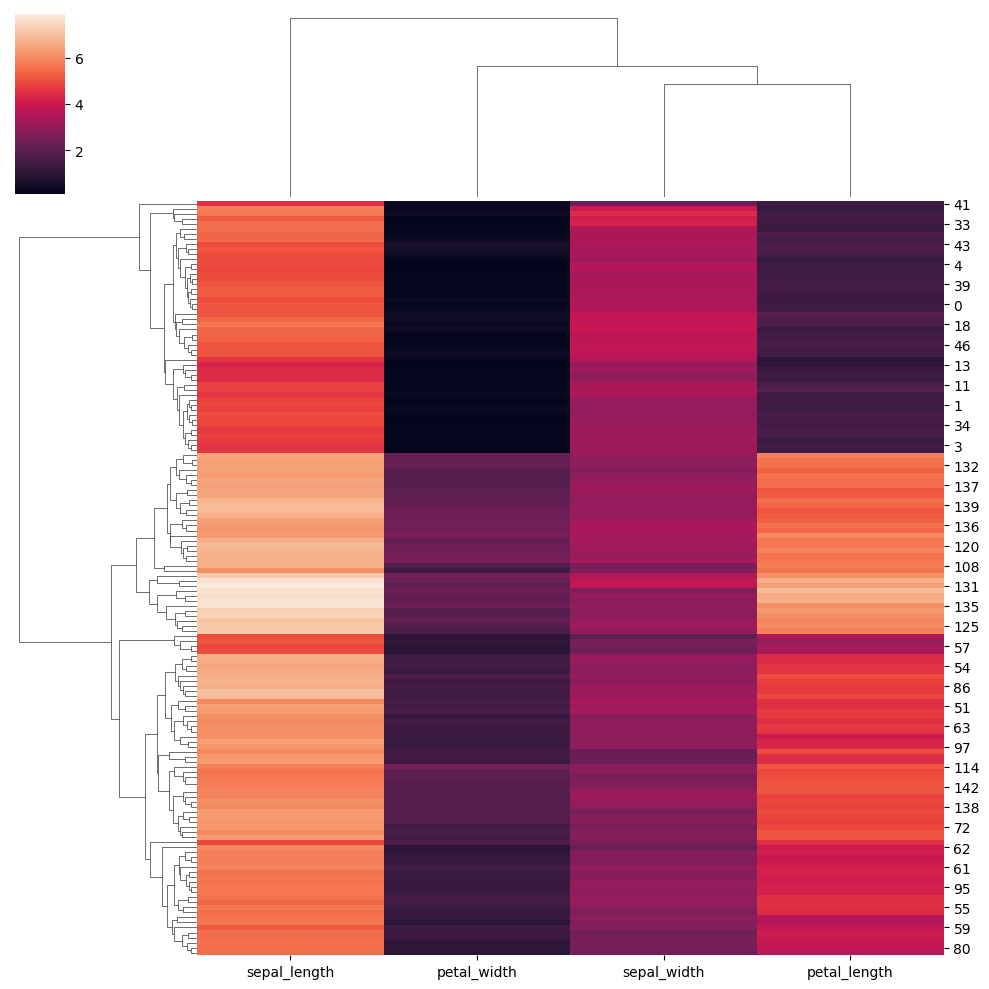

In [45]:
# Plotting clustermap
sns.clustermap(iris.iloc[:, [0, 1, 2, 3]])

**Figure size at figure level:** We can control the figure size using the `height` and `aspect` parameters. 

- height: sets the height (in inches) of each subplot.
- aspect: controls the aspect ratio of each subplot. The width of each subplot will be calculated as `height * aspect`.

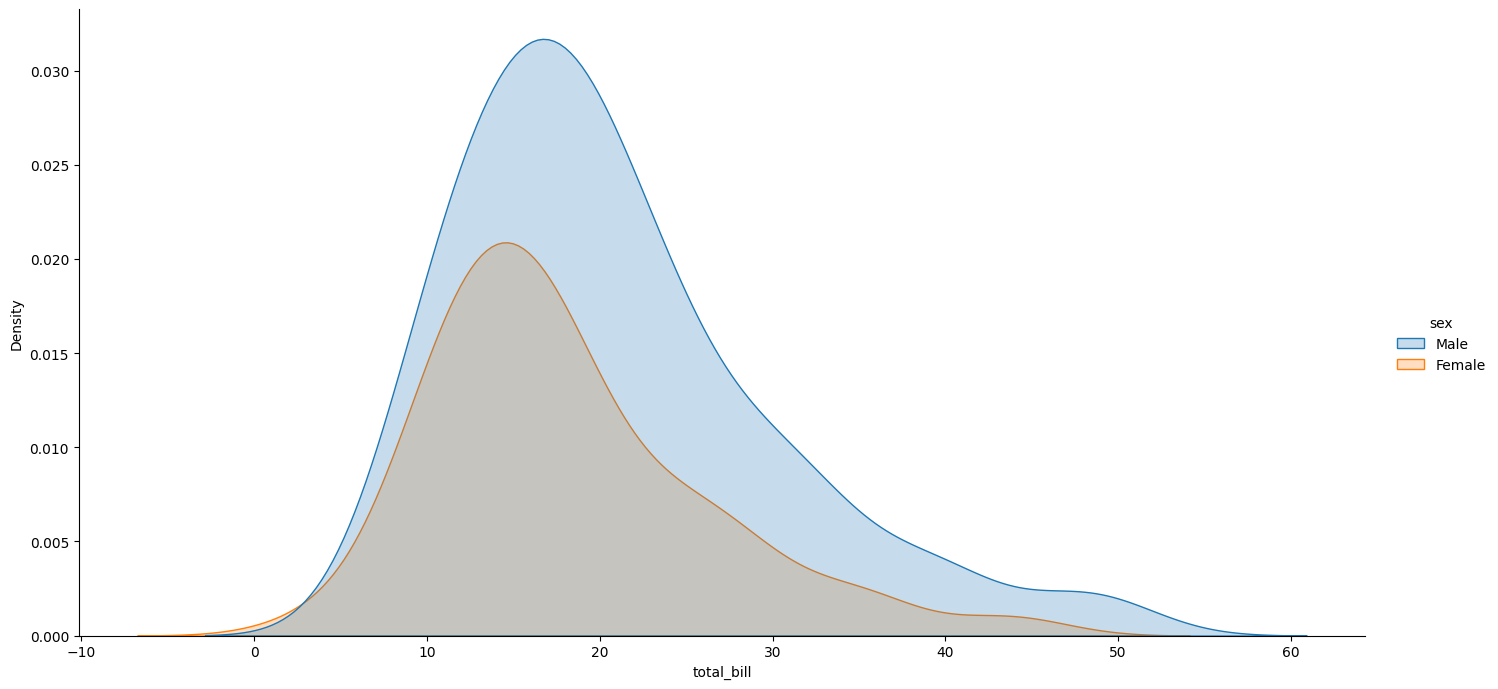

In [52]:
sns.displot(data=tips, x='total_bill', kind='kde', hue='sex', fill=True, height=7, aspect=2)

---